Taller #4 

Parte # 1

Ejercicio 1.1

In [4]:
notas = """Nota 1: Estudiar Python
Nota 2: Practicar APIs
Nota 3: Aprender Pillow
"""

# Escribir el archivo
with open ('mis_notas.txt', 'w', encoding='utf-8') as archivo :
    archivo.write ( notas )

print ("Archivo escrito exitosamente")

# Leer el archivo completo
with open ('mis_notas.txt', 'r', encoding='utf-8') as archivo :
    contenido = archivo.read ()
print ("Contenido del archivo :")
print ( contenido )

# Ahora lee el archivo linea por linea
# Tu codigo aqui
with open ('mis_notas.txt', 'r', encoding='utf-8') as archivo :
    print ("\nLeyendo linea por linea :")
    for linea in archivo :

        print ( linea.strip() )

Archivo escrito exitosamente
Contenido del archivo :
Nota 1: Estudiar Python
Nota 2: Practicar APIs
Nota 3: Aprender Pillow


Leyendo linea por linea :
Nota 1: Estudiar Python
Nota 2: Practicar APIs
Nota 3: Aprender Pillow


Ejercicio 1.2

In [11]:
import json

# Crear un diccionario con información de un estudiante
estudiante = {
    "nombre": "Juan Pérez",
    "edad": 2,
    "carrera": "Ingeniería",
    "materias": ["Python", "Matematicas", "Física"],
    "promedio": 4.2
}

# Guardar el diccionario en un archivo JSON
with open ('estudiante.json', 'w', encoding='utf-8') as archivo:
    json.dump( estudiante, archivo , indent=4, ensure_ascii=False )

print ("Archivo JSON guardado")

# Leer el archivo JSON
with open ('estudiante.json', 'r', encoding='utf-8') as archivo:
    datos = json.load(archivo)
    print ("\nDatos del archivo JSON:")
    print ( datos )

# Accede y muestra solo el nombre y las materias
nombre = datos.get("nombre")
materias = datos.get("materias")
print (f"\nEstudiante: {nombre}")
print (f"Materias: {materias}")

Archivo JSON guardado

Datos del archivo JSON:
{'nombre': 'Juan Pérez', 'edad': 2, 'carrera': 'Ingeniería', 'materias': ['Python', 'Matematicas', 'Física'], 'promedio': 4.2}

Estudiante: Juan Pérez
Materias: ['Python', 'Matematicas', 'Física']


Ejercicio 1.3

In [12]:
import csv

#Lista de productos
productos = [
    ['Producto', 'Precio', 'Cantidad'],
    ['Laptop', 1200000, 5],
    ['Mouse', 35000, 20],
    ['Teclado', 80000, 15],
    ['Monitor', 450000, 8]
]

#Escribir el archivo CSV
with open ('productos.csv', 'w', newline='', encoding='utf-8') as archivo:
    escritor = csv.writer(archivo)
    for fila in productos:
        escritor.writerow(fila)

print ("Archivo CSV creado")

#Leer el archivo CSV
with open ('productos.csv', 'r', encoding='utf-8') as archivo:
    lector = csv.reader(archivo)
    print ("\nContenido del CSV:")
    for fila in lector:
        print (fila)

total_inventario = 0
with open ('productos.csv', 'r', encoding='utf-8') as archivo:
    lector = csv.reader(archivo)
    next(lector)  # Saltar la primera fila (encabezado)
    for fila in lector:
        precio = float(fila[1])
        cantidad = int(fila[2])
        total_inventario += precio * cantidad

print(f"\nValor total del inventario: ${total_inventario:,.2f}")

Archivo CSV creado

Contenido del CSV:
['Producto', 'Precio', 'Cantidad']
['Laptop', '1200000', '5']
['Mouse', '35000', '20']
['Teclado', '80000', '15']
['Monitor', '450000', '8']

Valor total del inventario: $11,500,000.00


Parte 2


Ejercicio 2.1

In [16]:
import requests

# URL de la API de JSONPlaceholder (API de prueba gratuita )
url = 'https://jsonplaceholder.typicode.com/posts/1'

# Realizar peticion GET
respuesta = requests.get(url)

# Verificar el codigo de estado
print (f" Codigo de estado : { respuesta.status_code }")

# Mostrar la respuesta en formato JSON
datos = respuesta.json ()
print ("\nDatos recibidos :")
print ( datos )

# Ahora haz una peticion a otro endpoint
# Tu codigo aqui : obten la lista de usuarios ( endpoint : / users )
url_usuarios = 'https://jsonplaceholder.typicode.com/users'
respuesta_usuarios = requests.get(url_usuarios)

print (f"\nNumero de usuarios : {len ( respuesta_usuarios.json ())}")

 Codigo de estado : 200

Datos recibidos :
{'userId': 1, 'id': 1, 'title': 'sunt aut facere repellat provident occaecati excepturi optio reprehenderit', 'body': 'quia et suscipit\nsuscipit recusandae consequuntur expedita et cum\nreprehenderit molestiae ut ut quas totam\nnostrum rerum est autem sunt rem eveniet architecto'}

Numero de usuarios : 10


Ejercicio 2.2:

In [21]:
import requests

# Obtener lista de todos los posts
url = 'https://jsonplaceholder.typicode.com/posts'
respuesta = requests.get(url)
posts = respuesta.json()

print (f"Total de posts : {len ( posts )}")

# Filtrar posts del usuario con id = 1
posts_usuario_1 = []
for post in posts :
    if post ['userId'] == 1:
        posts_usuario_1.append ( post )

print (f"\nPosts del usuario 1: {len ( posts_usuario_1 )}")

# Mostrar titulos de los primeros 3 posts del usuario 1
print ("\nPrimeros 3 titulos:")
for i in range (3) :
    print (f"{i +1}. { posts_usuario_1 [i]['title']}")

# Tu codigo aqui : obten los comentarios del post con id =1
# Endpoint : https://jsonplaceholder.typicode.com/posts/1/comments
url_comentarios = 'https://jsonplaceholder.typicode.com/posts/1/comments'
respuesta_comentarios = requests.get(url_comentarios)
comentarios = respuesta_comentarios.json()

print (f"\nNumero de comentarios en el post 1: {len(comentarios)}")

# Muestra el email del primer comentario
if comentarios:
    print (f"Email del primer comentario: {comentarios[0]['email']}")

Total de posts : 100

Posts del usuario 1: 10

Primeros 3 titulos:
1. sunt aut facere repellat provident occaecati excepturi optio reprehenderit
2. qui est esse
3. ea molestias quasi exercitationem repellat qui ipsa sit aut

Numero de comentarios en el post 1: 5
Email del primer comentario: Eliseo@gardner.biz


Ejercicio 2.3:

In [24]:
import requests

def obtener_datos(url):
    """
    Funcion que realiza una peticion GET manejando errores
    """
    try:
        respuesta = requests.get (url,timeout =5)
        respuesta.raise_for_status () # Lanza excepcion si hay error HTTP
        return respuesta . json ()
    except requests.exceptions.ConnectionError:
        print ("Error : No se pudo conectar al servidor ")
        return None
    except requests.exceptions.Timeout :
        print ("Error : La peticion tardo demasiado ")
        return None
    except requests.exceptions.HTTPError as e:
        print (f"Error HTTP : {e}")
        return None
    except Exception as e:
        print (f"Error inesperado : {e}")
        return None

# Probar con URL v l i d a
print (" Prueba 1: URL valida ")
datos = obtener_datos ('https://jsonplaceholder.typicode.com/users/1')
if datos :
    print (f"Usuario obtenido : { datos ['name']}")

# Probar con URL invlida
print ("\nPrueba 2: URL invlida ")
datos =obtener_datos ('https://jsonplaceholder.typicode.com/usuarios/999')

# Tu codigo aqui : prueba con otra URL que genere error
# Por ejemplo , un endpoint que no existe
print ("\nPrueba 3: Endpoint no existe ")
datos = obtener_datos ('https://jsonplaceholder.typicode.com/posts/9999    ')

 Prueba 1: URL valida 
Usuario obtenido : Leanne Graham

Prueba 2: URL invlida 
Error HTTP : 404 Client Error: Not Found for url: https://jsonplaceholder.typicode.com/usuarios/999

Prueba 3: Endpoint no existe 
Error HTTP : 404 Client Error: Not Found for url: https://jsonplaceholder.typicode.com/posts/9999%20%20%20%20


Parte 3

Ejercicio 3.1

Tamaño : (800, 600)
Ancho : 800 pixeles 
Alto : 600 pixeles 
Modo : RGB
Formato : JPEG


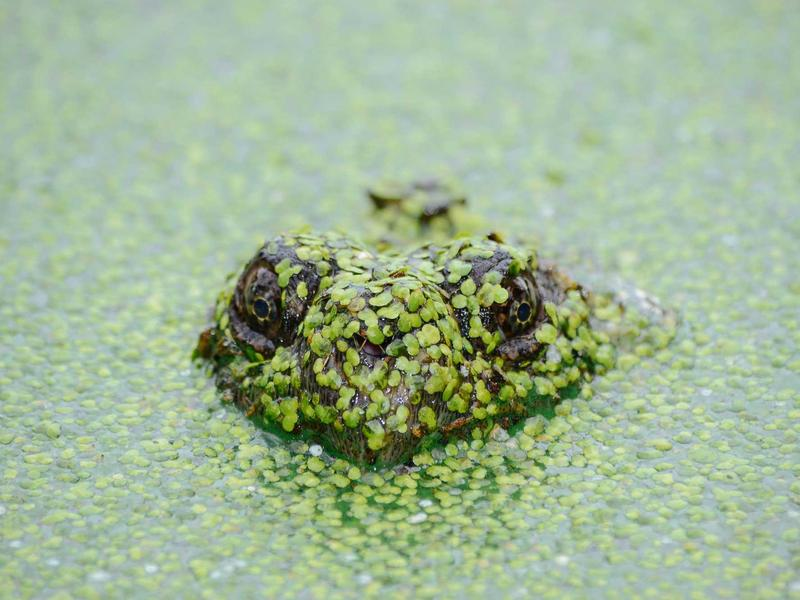

Imagen original guardada


In [25]:
from PIL import Image
import requests
from io import BytesIO

# Instala Pillow si es necesario :
# ! pip install Pillow

# Descargar una imagen de ejemplo desde internet
url_imagen = 'https://picsum.photos/800/600'
respuesta = requests.get ( url_imagen )
imagen = Image.open ( BytesIO ( respuesta.content ))

# Mostrar informacion de la imagen
print(f"Tamaño : { imagen.size }")
print(f"Ancho : { imagen.width } pixeles ")
print(f"Alto : { imagen.height } pixeles ")
print(f"Modo : { imagen.mode }")
print(f"Formato : { imagen.format }")

# Mostrar la imagen (en Colab se muestra automaticamente )
display( imagen )

# Tu codigo aqui : guarda la imagen original
imagen.save ('imagen_original.jpg')
print ("Imagen original guardada")


Ejercicio 3.2

Tamaño original : (800, 600)
Nuevo tamaño : (400, 300)
Imagen redimensionada guardada 


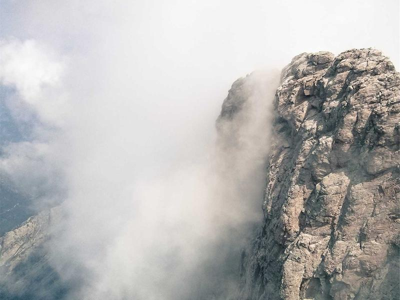

Tamaño de miniatura : (200, 150)
Miniatura guardada


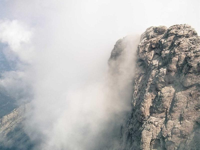


Thumbnail con proporcion : (200, 150)


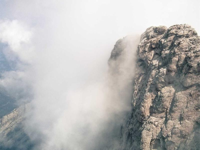

In [33]:
from PIL import Image
import requests
from io import BytesIO

# Cargar imagen ( usando la del ejercicio anterior o una nueva )
url_imagen = 'https://picsum.photos/800/600'
respuesta = requests.get(url_imagen)
imagen = Image.open(BytesIO( respuesta.content ))

print (f"Tamaño original : { imagen.size }")

# Redimensionar a 400 x300 pixeles
nuevo_tamanio = (400,300)
imagen_redimensionada = imagen.resize ( nuevo_tamanio )

print (f"Nuevo tamaño : { imagen_redimensionada.size }")

# Guardar la imagen redimensionada
imagen_redimensionada.save ('imagen_400x300.jpg')
print ("Imagen redimensionada guardada ")

# Mostrar imagen redimensionada
display (imagen_redimensionada )

# Tu codigo aqui : crea una miniatura de 200x150
miniatura = (200,150)
imagen_miniatura = imagen.copy()
imagen_miniatura = imagen_miniatura.resize ( miniatura )
print (f"Tamaño de miniatura : { imagen_miniatura.size }")
imagen_miniatura.save ('imagen_miniatura.jpg')
print ("Miniatura guardada")
display ( imagen_miniatura )

# Redimensionar manteniendo proporcion ( thumbnail )
imagen2 = Image.open ( BytesIO ( respuesta.content ))
imagen2.thumbnail ((200,200) ) # Mantiene proporcion
print (f"\nThumbnail con proporcion : { imagen2.size }")
display ( imagen2 )

Ejercicio 3.3

Modo original : RGB
Modo escala de grises: L

Imagen original :


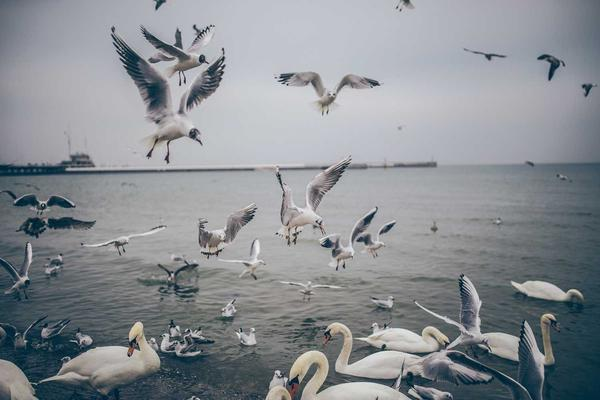


Imagen en escala de grises :


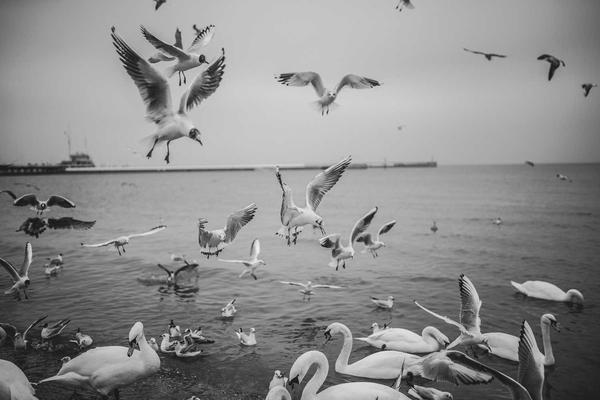


Modo blanco y negro : 1

Imagen en blanco y negro :


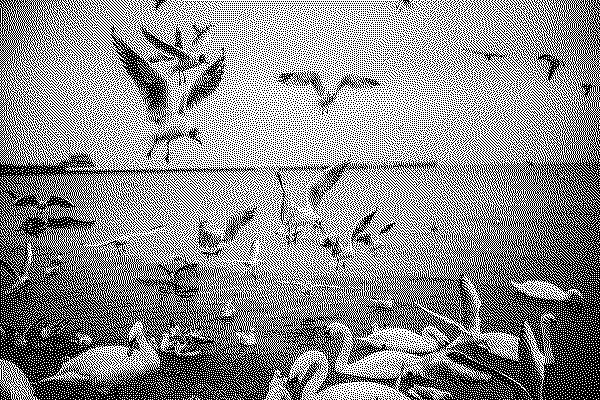

In [35]:
from PIL import Image
import requests
from io import BytesIO

# Cargar imagen
url_imagen = 'https://picsum.photos/600/400'
respuesta = requests.get ( url_imagen )
imagen = Image.open( BytesIO ( respuesta.content ))

print (f"Modo original : { imagen . mode }")

# Convertir a escala de grises
imagen_gris = imagen.convert ('L')
print (f"Modo escala de grises: { imagen_gris.mode }")

# Guardar imagen en escala de grises
imagen_gris.save ('imagen_gris.jpg')

# Mostrar ambas i m g e n e s
print ("\nImagen original :")
display ( imagen )
print ("\nImagen en escala de grises :")
display ( imagen_gris )

# Tu codigo aqui : convierte la imagen a blanco y negro puro
# Usa el modo ’1’ ( binario )
imagen_bn = imagen.convert('1')
print (f"\nModo blanco y negro : { imagen_bn.mode }")
# Tu codigo aqui : guarda y muestra la imagen
imagen_bn.save ('imagen_bn.jpg')
print ("\nImagen en blanco y negro :")
display ( imagen_bn )